In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

# Task 1

In [14]:
penguins = sns.load_dataset("penguins")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [16]:
penguins.info()

penguins.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [18]:
penguins_clean = penguins.dropna()

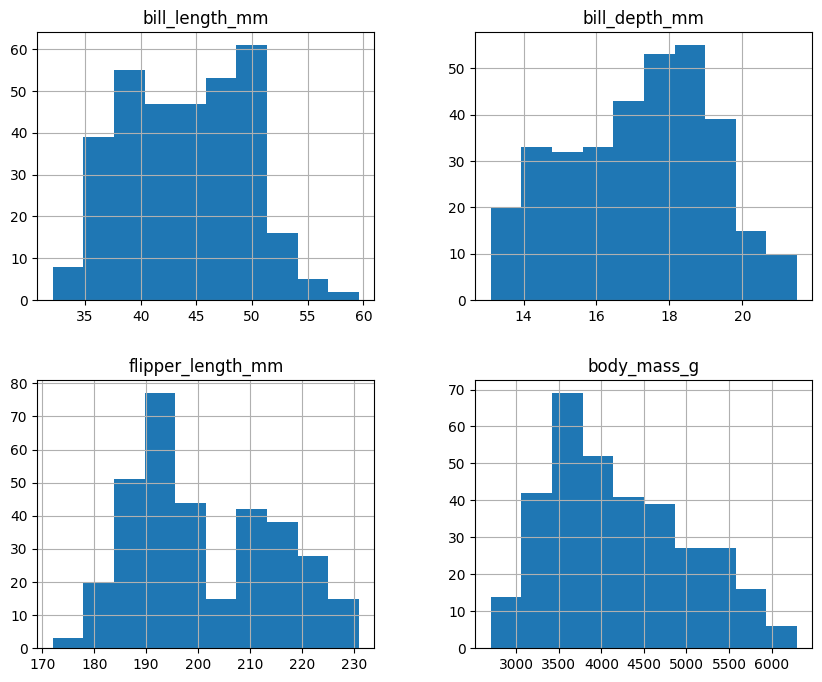

In [20]:
penguins_clean.hist(figsize=(10,8))
plt.show()

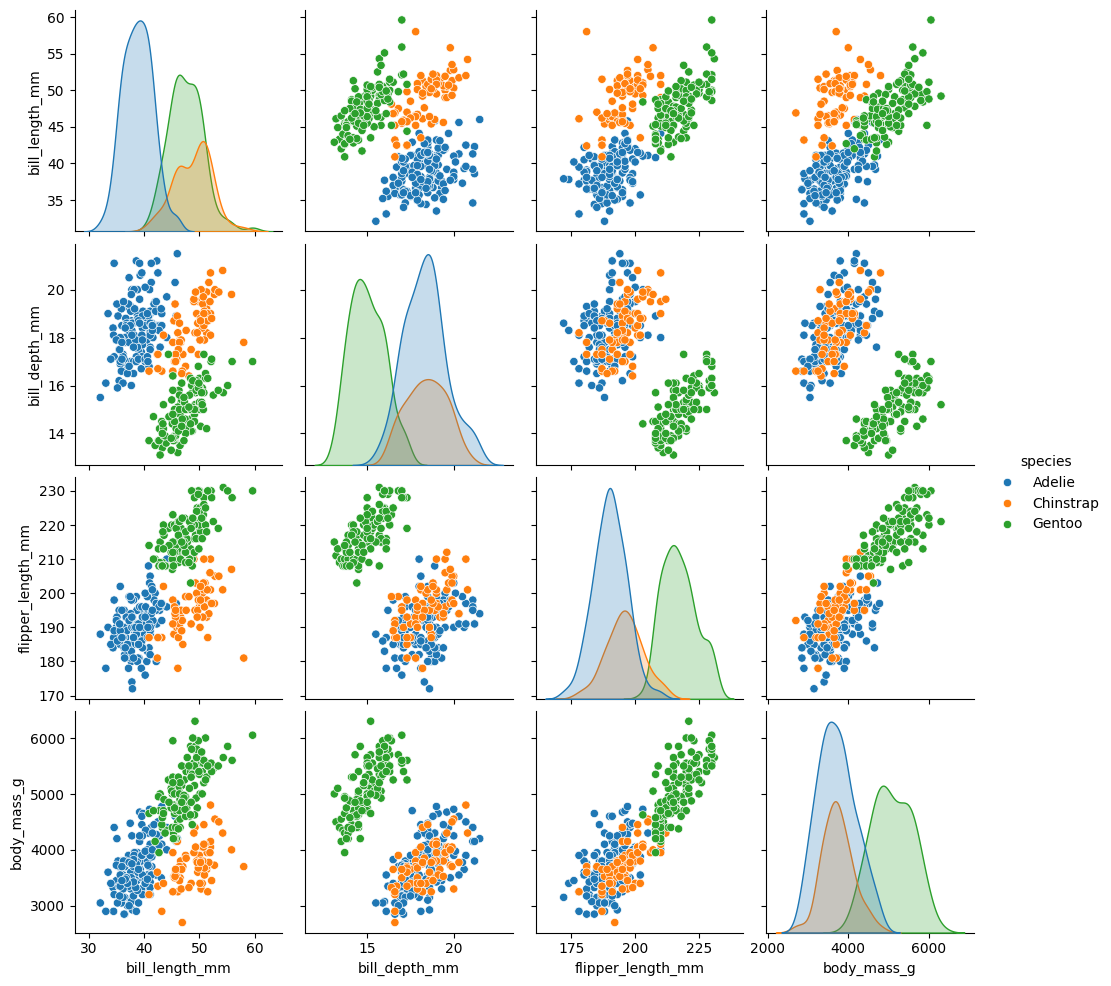

In [22]:
sns.pairplot(penguins_clean, hue="species")
plt.show()

In [24]:
numeric_features = penguins_clean.select_dtypes(include=np.number)

X_scaled = StandardScaler().fit_transform(numeric_features)

In [26]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

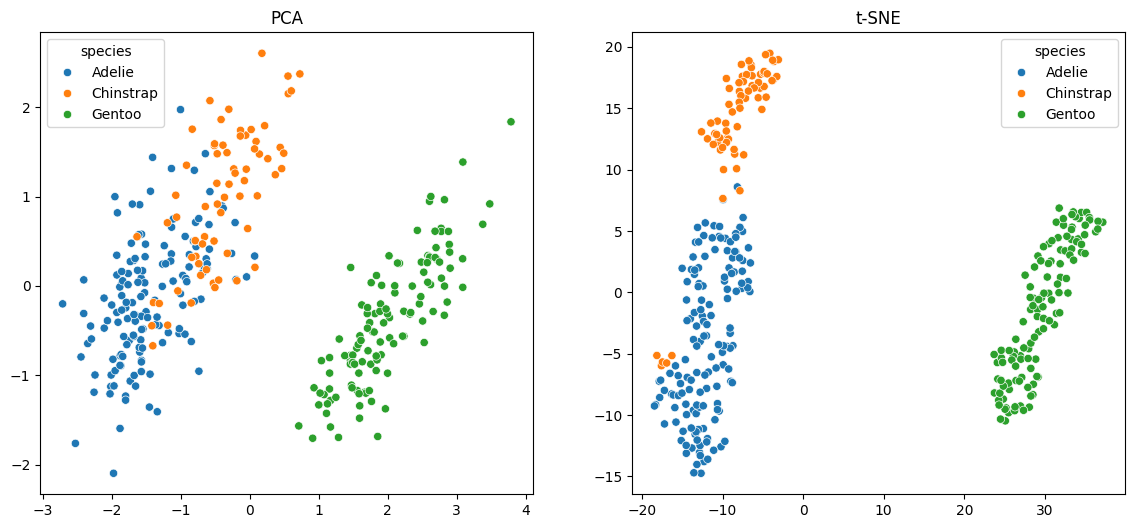

In [28]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=penguins_clean["species"],
    ax=axes[0]
)

axes[0].set_title("PCA")

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=penguins_clean["species"],
    ax=axes[1]
)

axes[1].set_title("t-SNE")

plt.show()

In [30]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)

print("KMeans Silhouette:", kmeans_silhouette)

KMeans Silhouette: 0.446192544665462


C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [32]:
dbscan1 = DBSCAN(eps=0.5, min_samples=5)
labels1 = dbscan1.fit_predict(X_scaled)

dbscan2 = DBSCAN(eps=1.0, min_samples=3)
labels2 = dbscan2.fit_predict(X_scaled)

In [34]:
if len(set(labels1)) > 1:
    print("DBSCAN 1 Silhouette:",
          silhouette_score(X_scaled, labels1))

if len(set(labels2)) > 1:
    print("DBSCAN 2 Silhouette:",
          silhouette_score(X_scaled, labels2))

DBSCAN 1 Silhouette: 0.25157063623102277
DBSCAN 2 Silhouette: 0.46691828883556735


In [36]:
ari = adjusted_rand_score(
    penguins_clean["species"],
    kmeans_labels
)

nmi = normalized_mutual_info_score(
    penguins_clean["species"],
    kmeans_labels
)

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.7994209859673324
NMI: 0.7899317532789121


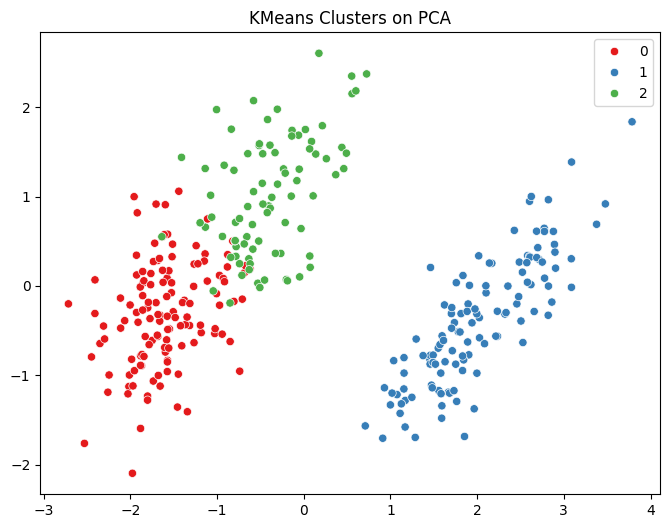

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette="Set1"
)

plt.title("KMeans Clusters on PCA")
plt.show()

K-Means recovered the species structure relatively well, especially separating Gentoo penguins. However, Adelie and Chinstrap overlapped in some regions. DBSCAN struggled because the dataset density was not uniform and some points were labeled as noise.

# Task 2

In [44]:
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [46]:
df = penguins.dropna()

X = df.drop("species", axis=1)
y = df["species"]

In [48]:
numeric_cols = X.select_dtypes(include=np.number).columns
categorical_cols = X.select_dtypes(exclude=np.number).columns

In [50]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(), categorical_cols)
])

In [52]:
models = {
    "LogisticRegression":
        LogisticRegression(max_iter=1000),

    "RandomForest":
        RandomForestClassifier(random_state=42),

    "SVC":
        SVC(probability=True)
}

In [54]:
results = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=[
            "accuracy",
            "precision_macro",
            "recall_macro",
            "f1_macro"
        ]
    )

    results[name] = {
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision_macro"].mean(),
        "Recall": scores["test_recall_macro"].mean(),
        "F1": scores["test_f1_macro"].mean()
    }

pd.DataFrame(results).T

,Accuracy,Precision,Recall,F1
LogisticRegression,0.997015,0.997778,0.995238,0.996401
RandomForest,0.991000,0.988889,0.990640,0.989464
SVC,0.997015,0.997778,0.995238,0.996401


In [56]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=42))
])

param_grid = {
    "model__n_estimators": [50,100,200],
    "model__max_depth": [None,5,10],
    "model__min_samples_split": [2,5]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1_macro"
)

grid.fit(X,y)

print(grid.best_params_)
print(grid.best_score_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
0.9894640382587312


# Task 3

In [58]:
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [62]:
best_model = grid.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           1.00        67
   macro avg       1.00      1.00      1.00        67
weighted avg       1.00      1.00      1.00        67



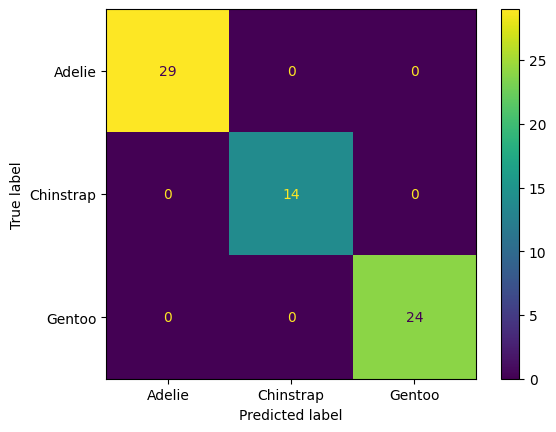

In [66]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

plt.show()

In [68]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(
    y_test,
    classes=np.unique(y)
)

y_probs = best_model.predict_proba(X_test)

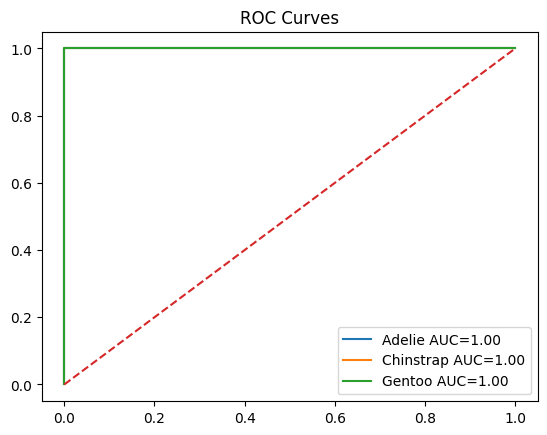

In [70]:
for i, species in enumerate(np.unique(y)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:,i],
        y_probs[:,i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr,
             label=f"{species} AUC={roc_auc:.2f}")

plt.plot([0,1],[0,1],"--")

plt.legend()
plt.title("ROC Curves")
plt.show()

In [72]:
from sklearn.model_selection import learning_curve

C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\model_selection\_validation.py:927: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\model_selection\_validation.py", line 916, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\metrics\_scorer.py", line 485, in __call__
    return estimator.score(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\pipeline.py", line 1131, in score
    Xt = transform.transform(Xt)
         ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\royan\anaconda3\envs\data_analysis\Lib\site-packages\sklearn\utils\_set_output.

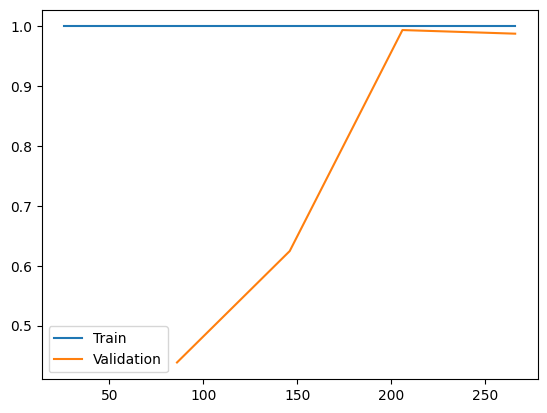

In [74]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5
)

plt.plot(train_sizes, train_scores.mean(axis=1),
         label="Train")

plt.plot(train_sizes, test_scores.mean(axis=1),
         label="Validation")

plt.legend()
plt.show()

In [76]:
from sklearn.inspection import permutation_importance

In [78]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

# Task 4

In [80]:
import joblib

joblib.dump(best_model, "best_penguin_model.joblib")

['best_penguin_model.joblib']

In [92]:
import requests

sample = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181,
    "body_mass_g": 3750,
    "island": "Torgersen",
    "sex": "Male"
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=sample
)

print(response.json())

{'prediction': 'Adelie', 'probabilities': {'Adelie': 1.0, 'Chinstrap': 0.0, 'Gentoo': 0.0}}


In [94]:
bad_sample = {
    "bill_length_mm": 39.1
}

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=bad_sample
)

print(response.json())

{'error': 'Missing field: bill_depth_mm'}
